RANDOM FOREST

Apply the Random Forest algorithm on a given dataset to predict the output class. Analyze the model  performance by varying the number of trees and comparing the results.  

In [3]:
# Import libraries
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [4]:
# -----------------------------------
# 1. Load Dataset
# -----------------------------------
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [5]:
# -----------------------------------
# 2. Preprocessing
# -----------------------------------

# Check missing values
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


In [6]:
# Remove duplicate rows
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [ ]:
X = X.drop_duplicates()

# Reset index
X = X.reset_index(drop=True)

# Keep target aligned after removing duplicates
y = y.loc[X.index].reset_index(drop=True)

In [8]:
# -----------------------------------
# 3. Train-Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
# -----------------------------------
# 4. Random Forest with Different Number of Trees
# -----------------------------------

tree_values = [10, 50, 100, 150, 200]

print("\nRandom Forest Accuracy Comparison")
print("----------------------------------")

accuracies = []

for n in tree_values:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy * 100)

    print(
        "Number of Trees:",
        n,
        "| Accuracy:",
        round(accuracy * 100, 2),
        "%"
    )


Random Forest Accuracy Comparison
----------------------------------
Number of Trees: 10 | Accuracy: 93.86 %
Number of Trees: 50 | Accuracy: 95.61 %
Number of Trees: 100 | Accuracy: 95.61 %
Number of Trees: 150 | Accuracy: 95.61 %
Number of Trees: 200 | Accuracy: 95.61 %


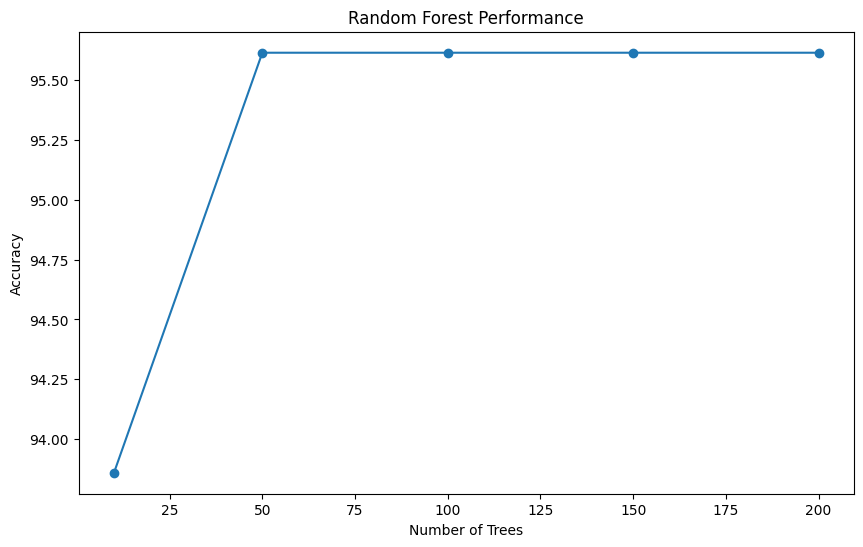

In [15]:
# Graphical representation of accuracy vs number of trees
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(tree_values,accuracies,marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance')
plt.show()

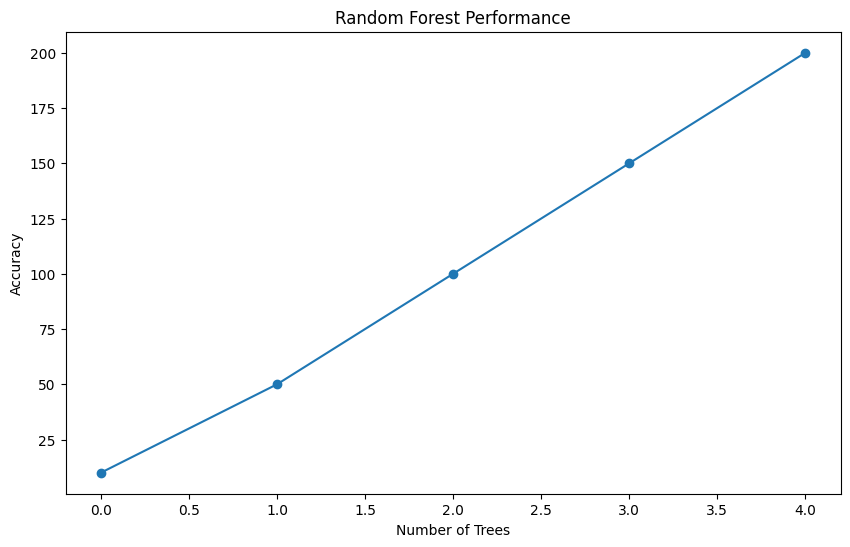

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(tree_values,marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance')
plt.show()